In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [8]:
# Модель входящего трафика: плавный рост RPS до предельного значения
def traffic(t, base=2500, peak=13000, midpoint=900, steepness=0.007):
    return base + (peak-base)/(1+np.exp(-steepness*(t-midpoint)))

# Основная симуляция автоскейлинга
def simulate_autoscaling(threshold=0.7, scale_down=0.45, k=3, tau=60, dt=10, t_end=3600,
                         pod_rps=1000, initial_pods=4, min_pods=3, max_pods=30,
                         hpa_period=30):
    # Создаём временную сетку: один шаг равен dt секунд
    times=np.arange(0,t_end+dt,dt)

    # Массив для хранения количества работающих подов
    pods=np.zeros(len(times), dtype=int)
    pods[0]=initial_pods

    # Очередь действий, которые сработают после задержки t
    pending=[]

    # История выполненных действий автоскейлера
    actions=[]

    for i in range(1, len(times)):
        t=times[i]
        p=pods[i-1]

        # Проверяем, какие ранее запрошенные поды уже запустились или отключились
        new_pending=[]
        for arr, delta in pending:
            if arr <= t + 1e-9:
                p=int(np.clip(p+delta, min_pods, max_pods))
                actions.append((t, delta, p))
            else:
                new_pending.append((arr, delta))
        pending=new_pending

        # Автоскейлер проверяет состояние не каждый шаг
        if abs(t % hpa_period) < 1e-9:
            D=traffic(t)
            capacity=max(p*pod_rps, 1)
            utilization=D/capacity

            # Если загрузка выше порога, добавляем k подов с задержкой t
            if utilization > threshold and p < max_pods:
                pending.append((t+tau, min(k, max_pods-p)))

            # Если загрузка слишком низкая, отключаем лишние поды с задержкой t
            elif utilization < scale_down and p > min_pods:
                pending.append((t+tau, -min(k, p-min_pods)))

        # Сохраняем количество подов на текущем шаге
        pods[i]=p

    # Считаем итоговые ряды для графиков и таблиц
    demand=np.array([traffic(t) for t in times])
    capacity=pods*pod_rps
    utilization=demand/np.maximum(capacity, 1)
    return times, demand, pods, capacity, utilization, actions


# Поиск момента, когда система стала устойчивой
def stabilization_time(times, utilization, lower=0.55, upper=0.85, window=12):
    # Считаем устойчивым режим, где загрузка держится в допустимых границах
    ok=(utilization>=lower)&(utilization<=upper)

    for i,t in enumerate(times):
        # Первые 10 минут не считаем стабилизацией, так как идёт рост нагрузки
        if t < 600:
            continue

        # Проверяем окно и оставшуюся часть графика
        if i+window < len(times) and ok[i:i+window].all() and ok[i:].mean() > 0.95:
            return int(t/10), int(t)

    # Если устойчивость не найдена
    return None, None


# Модель Хатчинсона с возможным эффектом Олли
def simulate_hutchinson_allee(y0=5000, K=15000, A=4000, r=0.04, tau_steps=12, dt=1, steps=180, allee=False):
    # y - эффективная мощность системы во времени
    y=np.zeros(steps+1)

    # До появления задержанных значений считаем мощность начальной
    y[:tau_steps+1]=y0

    for n in range(tau_steps, steps):
        # Берём значение с задержкой
        y_delay=y[n-tau_steps]

        # Логистический рост с запаздыванием Хатчинсона
        growth=r*y[n]*(1-y_delay/K)

        # Если включён эффект Олли, добавляем критический порог
        if allee:
            growth *= (y[n]/A - 1)

        # Обновляем значение и не даём уйти ниже нуля
        y[n+1]=max(0, y[n] + growth*dt)

        # Ограничиваем слишком большой перелёт для читаемости графика
        if y[n+1] > 3*K:
            y[n+1]=3*K

    return np.arange(steps+1)*dt, y

In [9]:
# Набор сценариев для сравнения
# Название, порог загрузки A, добавляемые поды k, задержка t
scenarios=[
    ('Быстрый',0.70,3,30),
    ('Средняя',0.70,3,60),
    ('Большая',0.70,3,120),
    ('Агрессивная',0.60,5,120),
]

# Собираем итоговую таблицу по каждому сценарию
rows=[]
for name,A,k,tau in scenarios:
    # Запускаем симуляцию
    times,D,pods,cap,u,actions=simulate_autoscaling(threshold=A,k=k,tau=tau)

    # Ищем время стабилизации
    step,t_stab=stabilization_time(times,u)

    # Сохраняем ключевые показатели
    rows.append({
        'Сценарий':name,'A, %':int(A*100),'k':k,'τ, с':tau,
        'Макс. загрузка, %':round(float(u.max()*100),1),'Макс. подов':int(pods.max()),
        'Итог подов':int(pods[-1]),'Шаг стаб.':step,'Время стаб., с':t_stab
    })

# Выводим таблицу результатов
summary=pd.DataFrame(rows)
summary


,Сценарий,"A, %",k,"τ, с","Макс. загрузка, %",Макс. подов,Итог подов,Шаг стаб.,"Время стаб., с"
0,Быстрый,70,3,30,84.7,19,19,63.0,630.0
1,Средняя,70,3,60,149.6,19,19,84.0,840.0
2,Большая,70,3,120,234.0,21,21,117.0,1170.0
3,Агрессивная,60,5,120,384.5,30,20,NaN,NaN


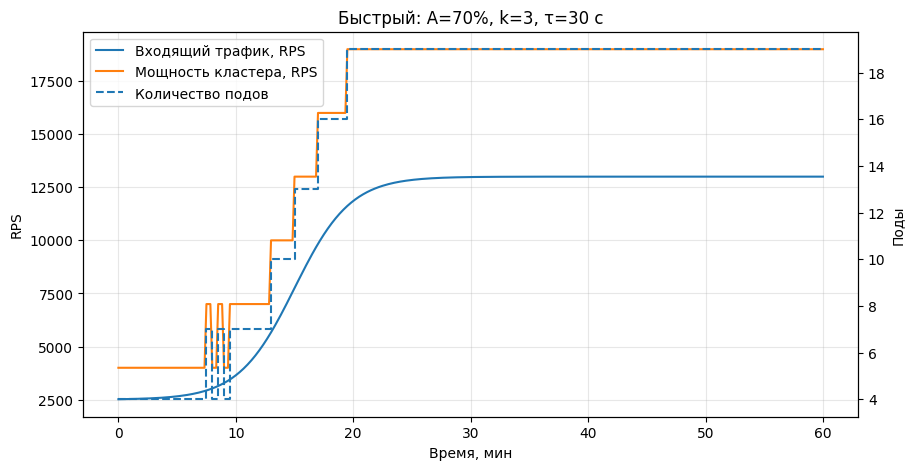

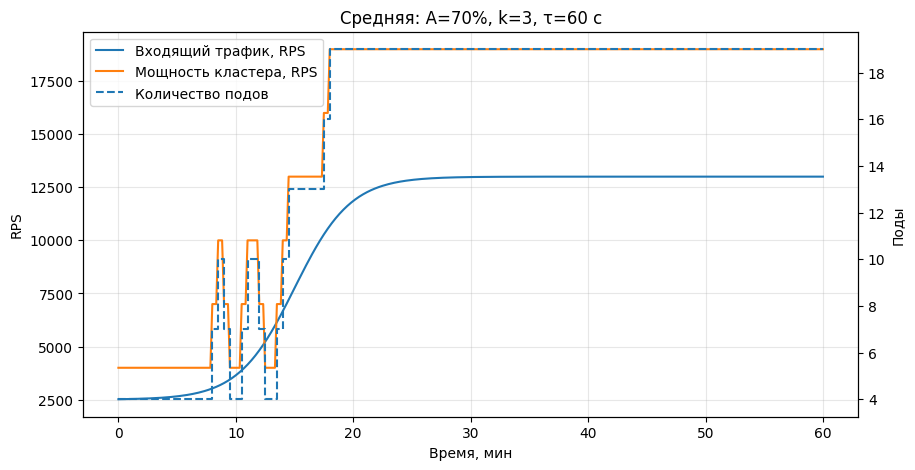

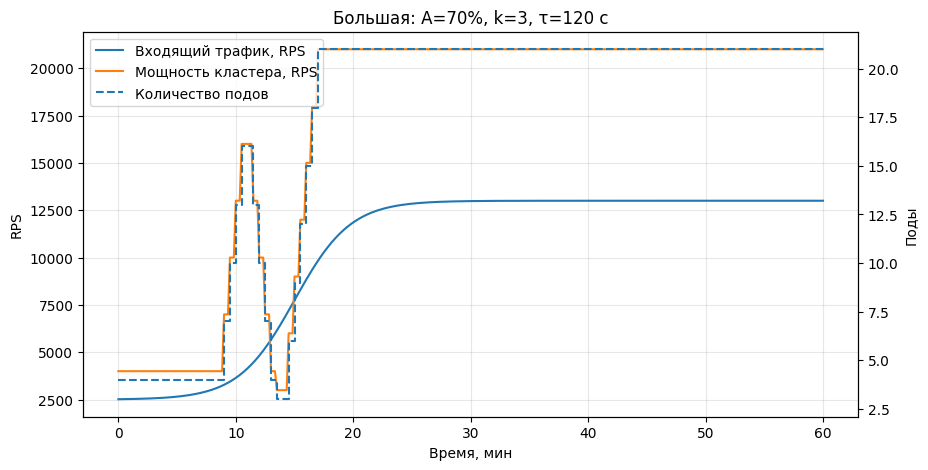

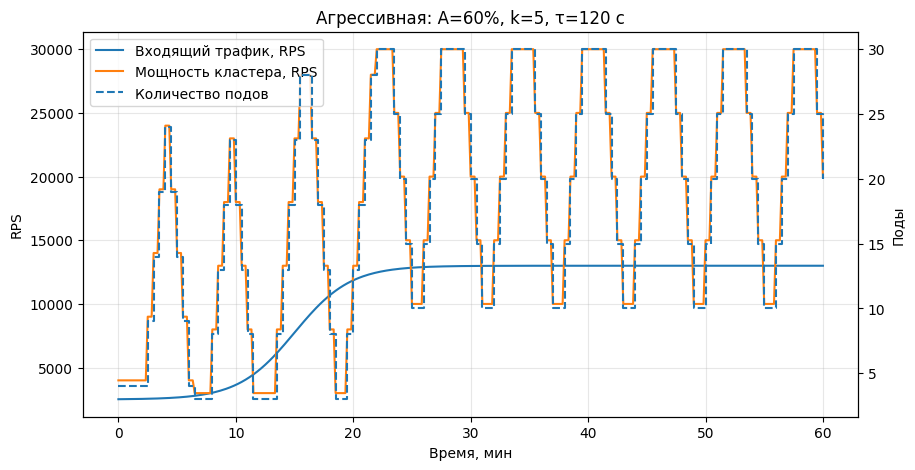

In [10]:
# Функция для построения графика одного сценария
def plot_scenario(name,A,k,tau):
    # Запускаем симуляцию для заданных параметров
    times,D,pods,cap,u,actions=simulate_autoscaling(threshold=A,k=k,tau=tau)

    # Первый график: входящий трафик и мощность кластера
    fig, ax1 = plt.subplots(figsize=(10,5))
    ax1.plot(times/60,D,label='Входящий трафик, RPS')
    ax1.plot(times/60,cap,label='Мощность кластера, RPS')
    ax1.set_xlabel('Время, мин')
    ax1.set_ylabel('RPS')
    ax1.grid(True, alpha=0.3)

    # Вторая ось: количество подов
    ax2=ax1.twinx()
    ax2.step(times/60,pods,where='post',linestyle='--',label='Количество подов')
    ax2.set_ylabel('Поды')

    # Объединяем легенды с двух осей
    lines,labels=ax1.get_legend_handles_labels()
    lines2,labels2=ax2.get_legend_handles_labels()
    ax1.legend(lines+lines2,labels+labels2,loc='upper left')

    # Заголовок с параметрами сценария
    plt.title(f'{name}: A={int(A*100)}%, k={k}, τ={tau} с')
    plt.show()

# Строим графики для всех сценариев
for sc in scenarios:
    plot_scenario(*sc)


In [11]:
# Перебираем разные настройки, чтобы найти устойчивый вариант
search_rows=[]
for A in [0.60,0.65,0.70,0.75,0.80]:
    for k in [1,2,3,4,5,6]:
        for tau in [30,60,90,120]:
            # Запускаем симуляцию для очередной комбинации параметров
            times,D,pods,cap,u,actions=simulate_autoscaling(threshold=A,k=k,tau=tau)

            # Проверяем, стабилизировалась ли система
            step,t_stab=stabilization_time(times,u)

            # Берём только устойчивые варианты
            if step is not None:
                search_rows.append({
                    'A':A,'k':k,'tau':tau,'step':step,'t_stab':t_stab,
                    'max_util':float(u.max()),'max_pods':int(pods.max()),
                    'final_pods':int(pods[-1]),
                    'osc':float(np.std(pods[times>1600])), # колебания после разгона
                    'actions':len(actions) # число действий автоскейлера
                })

# Сортируем: быстрее стабилизация, меньше колебания, меньше подов и действий
search=pd.DataFrame(search_rows).sort_values(['step','osc','max_pods','actions']).reset_index(drop=True)
search.head(10)


,A,k,tau,step,t_stab,max_util,max_pods,final_pods,osc,actions
0,0.75,2,30,60,600,0.847186,18,18,0.0,7
1,0.80,2,30,60,600,0.877471,18,18,0.0,7
2,0.75,1,30,60,600,0.854861,18,18,0.0,14
3,0.80,1,60,60,600,0.918916,18,18,0.0,14
4,0.70,1,30,60,600,0.787643,19,19,0.0,15
5,0.75,1,60,60,600,0.918916,19,19,0.0,15
6,0.75,1,90,60,600,1.002824,19,19,0.0,15
7,0.70,2,30,60,600,0.782696,20,20,0.0,8
8,0.65,2,30,60,600,0.725603,20,20,0.0,12
9,0.65,1,30,60,600,0.726160,20,20,0.0,16


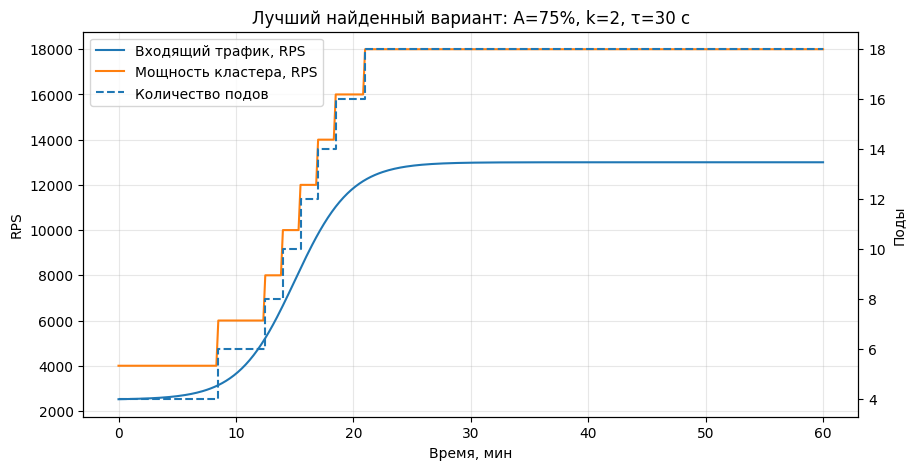

In [12]:
# Берём лучший вариант из таблицы подбора
best=search.iloc[0]

# Строим для него отдельный график
plot_scenario('Лучший найденный вариант', best['A'], int(best['k']), int(best['tau']))


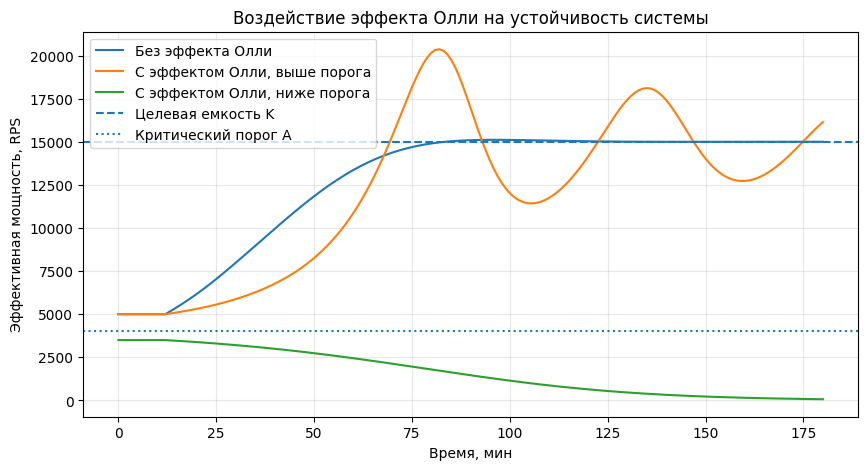

In [13]:
# Сценарий без эффекта Олли
# Система может восстановиться, если не учитывать критический порог
t,y1=simulate_hutchinson_allee(y0=5000, K=15000, A=4000, r=0.04, tau_steps=12, allee=False)

# Сценарий с эффектом Олли, но начальное значение выше порога
# Система должна выйти к устойчивому уровню
_,y2=simulate_hutchinson_allee(y0=5000, K=15000, A=4000, r=0.04, tau_steps=12, allee=True)

# Сценарий с эффектом Олли, но начальное значение ниже порога
# Система должна уйти к отказу
_,y3=simulate_hutchinson_allee(y0=3500, K=15000, A=4000, r=0.04, tau_steps=12, allee=True)

# Строим сравнение трёх вариантов
plt.figure(figsize=(10,5))
plt.plot(t,y1,label='Без эффекта Олли')
plt.plot(t,y2,label='С эффектом Олли, выше порога')
plt.plot(t,y3,label='С эффектом Олли, ниже порога')

# Показываем емкость среды и критический порог
plt.axhline(15000, linestyle='--', label='Целевая емкость K')
plt.axhline(4000, linestyle=':', label='Критический порог A')

plt.xlabel('Время, мин')
plt.ylabel('Эффективная мощность, RPS')
plt.grid(True, alpha=0.3)
plt.legend()
plt.title('Воздействие эффекта Олли на устойчивость системы')
plt.show()
